# wsel as a function of (m0, m2/m0)

This notebook builds the 2D distribution of mean `wsel` on a log-spaced grid in `(m0, m2/m0)`, using the pre-computed per-object arrays produced by `collect_m2_m0.py`. The collected file contains objects from **all six fields** (spring1/2/3, autumn1/2, hectomap), so the plots and fits are automatically over the full footprint.

In [1]:
import fitsio
import numpy as np
import matplotlib.pyplot as plt

In [23]:
COLLECTED_PATH_ZBEST = (
    "/gpfs02/work/xiangchong.li/work/hsc_data/s23b/"
    "deepCoadd_anacal_v2/m2_m0_collected_zbest.fits"
)
COLLECTED_PATH_ZMODE = (
    "/gpfs02/work/xiangchong.li/work/hsc_data/s23b/"
    "deepCoadd_anacal_v2/m2_m0_collected_zmode.fits"
)
# Choose which one to use
COLLECTED_PATH = COLLECTED_PATH_ZBEST
ngrid = 10


In [24]:
# Load pre-computed per-object arrays (all fields, produced by collect_m2_m0.py)
d = fitsio.read(COLLECTED_PATH)
m0 = d["m0"].astype(np.float64)
m2 = d["m2"].astype(np.float64)
w = d["wsel"].astype(np.float64)
e1 = d["e1"].astype(np.float64)
e2 = d["e2"].astype(np.float64)
# Per-object shear response: (de1/dg1 + de2/dg2) / 2, unweighted
resp_per_obj = d["resp"].astype(np.float64)
trace = m2 / m0
print(f"Loaded {len(m0)} objects from all fields")

Loaded 52104259 objects from all fields


In [25]:
# 2D grid with log-spaced bins in (m0, m2/m0)
m0_edges = np.logspace(np.log10(2), np.log10(1500), ngrid + 1)
trace_edges = np.logspace(np.log10(0.05), np.log10(3.0), ngrid + 1)

i_m0 = np.digitize(m0, m0_edges) - 1
i_tr = np.digitize(trace, trace_edges) - 1

wsel_grid = np.full((ngrid, ngrid), np.nan)
sigma2_grid = np.full((ngrid, ngrid), np.nan)
resp_grid = np.full((ngrid, ngrid), np.nan)
count_grid = np.zeros((ngrid, ngrid), dtype=int)
m0_center = np.zeros((ngrid, ngrid))
trace_center = np.zeros((ngrid, ngrid))

for ix in range(ngrid):
    for iy in range(ngrid):
        sel = (i_m0 == ix) & (i_tr == iy)
        n = int(np.sum(sel))
        count_grid[ix, iy] = n
        if n < 10:
            continue
        m0_center[ix, iy] = np.exp(np.mean(np.log(m0[sel])))
        trace_center[ix, iy] = np.exp(np.mean(np.log(trace[sel])))
        wsel_grid[ix, iy] = np.mean(w[sel])
        # sigma2 = var(e1) + var(e2) per bin
        sigma2_grid[ix, iy] = np.var(e1[sel]) + np.var(e2[sel])
        resp_grid[ix, iy] = np.mean(resp_per_obj[sel])

print("m0 edges:", np.round(m0_edges, 3))
print("m2/m0 edges:", np.round(trace_edges, 4))
print("Counts per bin:")
print(count_grid)


m0 edges: [   2.       3.877    7.517   14.573   28.252   54.772  106.186  205.86
  399.097  773.722 1500.   ]
m2/m0 edges: [0.05   0.0753 0.1134 0.1708 0.2572 0.3873 0.5833 0.8784 1.3228 1.9921
 3.    ]
Counts per bin:
[[ 151181  307662  658929 1389978 2485821 3118598 2125253  484669   15442
        6]
 [ 151634  365173  891938 1925237 3245958 3931025 2803234  713158   26767
        6]
 [ 107111  263972  669567 1480825 2506814 3250152 2646149  755427   26248
        1]
 [  65894  106575  270742  718547 1353742 1914929 1841389  632439   16474
        0]
 [  39765   39950   84788  288283  670549 1026954 1100697  479513   10541
        0]
 [  26634   20127   26212   98588  312447  557731  568080  303449    9827
        0]
 [  13449    9115    8036   23781  118156  302043  261957  133375    4058
        1]
 [   2746    1911    1554    3016   23002  118195   99772   26052     250
        0]
 [     22      26      41      50     908   14183   18612    1110       5
        0]
 [      0      

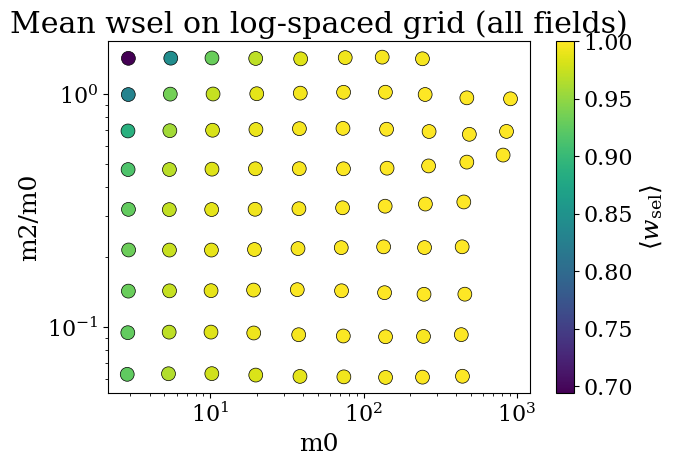

In [26]:
# 2D scatter plot of mean(wsel) on the log grid
valid = ~np.isnan(wsel_grid)
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    m0_center[valid], trace_center[valid],
    c=wsel_grid[valid], s=100,
    cmap="viridis", edgecolors="k", linewidths=0.5,
)
plt.colorbar(sc, ax=ax, label=r"$\langle w_{\rm sel} \rangle$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("m0")
ax.set_ylabel("m2/m0")
ax.set_title("Mean wsel on log-spaced grid (all fields)")
plt.tight_layout()
plt.show()

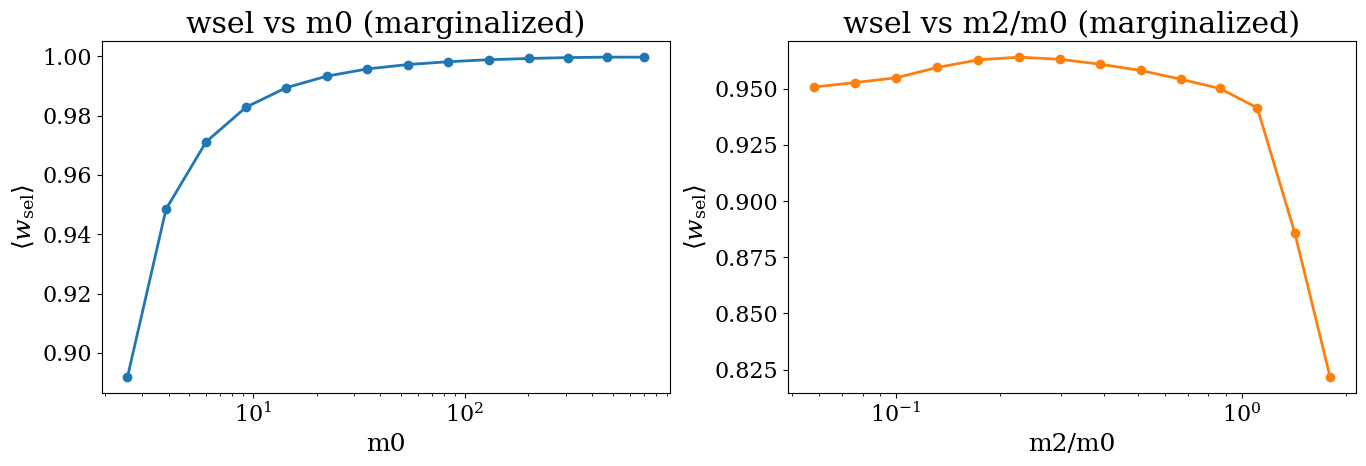

In [27]:
# 1D marginal: mean wsel vs m0 (marginalize over m2/m0)
nbins_1d = 15
m0_edges_1d = np.logspace(np.log10(2), np.log10(1500), nbins_1d + 1)
i_m0_1d = np.digitize(m0, m0_edges_1d) - 1

wsel_vs_m0 = np.full(nbins_1d, np.nan)
m0_centers_1d = np.full(nbins_1d, np.nan)
for ib in range(nbins_1d):
    sel = i_m0_1d == ib
    if np.sum(sel) < 100:
        continue
    m0_centers_1d[ib] = np.exp(np.mean(np.log(m0[sel])))
    wsel_vs_m0[ib] = np.mean(w[sel])

# 1D marginal: mean wsel vs m2/m0 (marginalize over m0)
trace_edges_1d = np.logspace(np.log10(0.05), np.log10(3.0), nbins_1d + 1)
i_tr_1d = np.digitize(trace, trace_edges_1d) - 1

wsel_vs_tr = np.full(nbins_1d, np.nan)
tr_centers_1d = np.full(nbins_1d, np.nan)
for ib in range(nbins_1d):
    sel = i_tr_1d == ib
    if np.sum(sel) < 100:
        continue
    tr_centers_1d[ib] = np.exp(np.mean(np.log(trace[sel])))
    wsel_vs_tr[ib] = np.mean(w[sel])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
valid_m0 = ~np.isnan(wsel_vs_m0)
ax.plot(m0_centers_1d[valid_m0], wsel_vs_m0[valid_m0], "o-", color="C0")
ax.set_xscale("log")
ax.set_xlabel("m0")
ax.set_ylabel(r"$\langle w_{\rm sel} \rangle$")
ax.set_title("wsel vs m0 (marginalized)")

ax = axes[1]
valid_tr = ~np.isnan(wsel_vs_tr)
ax.plot(tr_centers_1d[valid_tr], wsel_vs_tr[valid_tr], "o-", color="C1")
ax.set_xscale("log")
ax.set_xlabel("m2/m0")
ax.set_ylabel(r"$\langle w_{\rm sel} \rangle$")
ax.set_title("wsel vs m2/m0 (marginalized)")

plt.tight_layout()
plt.show()

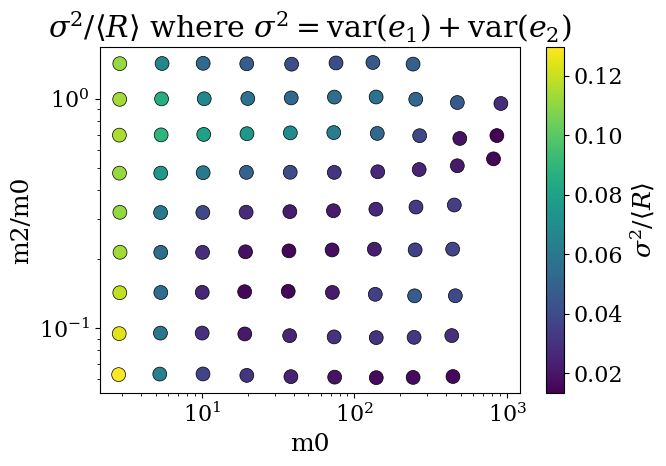

In [28]:
# 2D scatter plot of sigma2 / <R> on the log grid
# sigma2 = var(e1) + var(e2) per bin, unweighted
valid_s = ~np.isnan(sigma2_grid) & ~np.isnan(resp_grid) & (resp_grid != 0)
metric = sigma2_grid / resp_grid

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    m0_center[valid_s], trace_center[valid_s],
    c=metric[valid_s], s=100,
    cmap="viridis", edgecolors="k", linewidths=0.5,
)
plt.colorbar(sc, ax=ax, label=r"$\sigma^2 / \langle R \rangle$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("m0")
ax.set_ylabel("m2/m0")
ax.set_title(r"$\sigma^2 / \langle R \rangle$ where $\sigma^2 = \mathrm{var}(e_1)+\mathrm{var}(e_2)$")
plt.tight_layout()


<R>/sigma2 vs m0 fit: A=4.1117, B=5.9462 (y = A*ln(m0) + B)


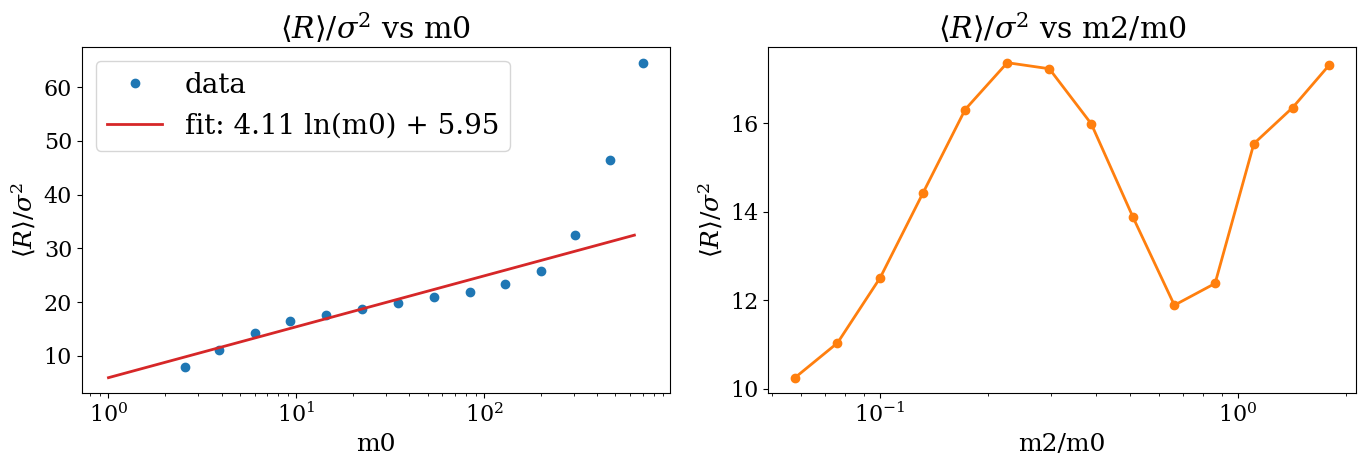

In [29]:
# 1D: <R> / sigma2 vs m0 (marginalized) with weighted linear fit
# sigma2 = var(e1) + var(e2)
nbins_1d = 15
m0_edges_1d = np.logspace(np.log10(2), np.log10(1500), nbins_1d + 1)
trace_edges_1d = np.logspace(np.log10(0.05), np.log10(3.0), nbins_1d + 1)
i_m0_1d = np.digitize(m0, m0_edges_1d) - 1
i_tr_1d = np.digitize(trace, trace_edges_1d) - 1

ratio_vs_m0 = np.full(nbins_1d, np.nan)
m0_centers_1d = np.full(nbins_1d, np.nan)
count_m0_1d = np.zeros(nbins_1d, dtype=int)
for ib in range(nbins_1d):
    sel = i_m0_1d == ib
    n = int(np.sum(sel))
    count_m0_1d[ib] = n
    if n < 100:
        continue
    s2 = np.var(e1[sel]) + np.var(e2[sel])
    if s2 <= 0:
        continue
    m0_centers_1d[ib] = np.exp(np.mean(np.log(m0[sel])))
    ratio_vs_m0[ib] = np.mean(resp_per_obj[sel]) / s2

ratio_vs_tr = np.full(nbins_1d, np.nan)
tr_centers_1d = np.full(nbins_1d, np.nan)
for ib in range(nbins_1d):
    sel = i_tr_1d == ib
    n = int(np.sum(sel))
    if n < 100:
        continue
    s2 = np.var(e1[sel]) + np.var(e2[sel])
    if s2 <= 0:
        continue
    tr_centers_1d[ib] = np.exp(np.mean(np.log(trace[sel])))
    ratio_vs_tr[ib] = np.mean(resp_per_obj[sel]) / s2

# Fit y = A * ln(m0) + B, weighted by sqrt(count) per bin
valid_m0 = ~np.isnan(ratio_vs_m0) & (m0_centers_1d < 200)
wt_fit = np.sqrt(count_m0_1d[valid_m0].astype(float))
coeffs_ratio = np.polyfit(
    np.log(m0_centers_1d[valid_m0]),
    ratio_vs_m0[valid_m0],
    1, w=wt_fit,
)
A_ratio, B_ratio = coeffs_ratio
print(f"<R>/sigma2 vs m0 fit: A={A_ratio:.4f}, B={B_ratio:.4f} (y = A*ln(m0) + B)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
valid_all = ~np.isnan(ratio_vs_m0)
ax.plot(m0_centers_1d[valid_all], ratio_vs_m0[valid_all], "o", color="C0", label="data")
xfit = np.logspace(0, 2.8, 500)
yfit = A_ratio * np.log(xfit) + B_ratio
ax.plot(xfit, yfit, "-", color="C3", label=f"fit: {A_ratio:.2f} ln(m0) + {B_ratio:.2f}")
ax.set_xscale("log")
ax.set_xlabel("m0")
ax.set_ylabel(r"$\langle R \rangle / \sigma^2$")
ax.set_title(r"$\langle R \rangle / \sigma^2$ vs m0")
ax.legend()

ax = axes[1]
valid_tr = ~np.isnan(ratio_vs_tr)
ax.plot(tr_centers_1d[valid_tr], ratio_vs_tr[valid_tr], "o-", color="C1")
ax.set_xscale("log")
ax.set_xlabel("m2/m0")
ax.set_ylabel(r"$\langle R \rangle / \sigma^2$")
ax.set_title(r"$\langle R \rangle / \sigma^2$ vs m2/m0")

plt.tight_layout()
plt.show()


ln(sigma2) vs m0 fit: A=-0.1305, B=-3.4754 (y = A*ln(m0) + B)


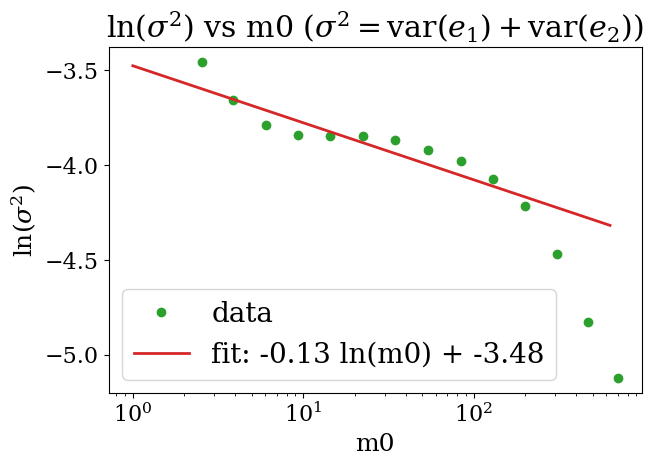

In [30]:
# 1D: ln(sigma2) vs m0 (natural log, e-base) with weighted linear fit
# sigma2 = var(e1) + var(e2)
ln_sigma2_vs_m0 = np.full(nbins_1d, np.nan)
m0c_s2 = np.full(nbins_1d, np.nan)
for ib in range(nbins_1d):
    sel = i_m0_1d == ib
    if np.sum(sel) < 100:
        continue
    s2 = np.var(e1[sel]) + np.var(e2[sel])
    if s2 <= 0:
        continue
    m0c_s2[ib] = np.exp(np.mean(np.log(m0[sel])))
    ln_sigma2_vs_m0[ib] = np.log(s2)

# Fit ln(sigma2) = A * ln(m0) + B, weighted by sqrt(count)
valid_s = ~np.isnan(ln_sigma2_vs_m0) & (m0c_s2 < 200)
wt_s = np.sqrt(count_m0_1d[valid_s].astype(float))
coeffs_ln = np.polyfit(np.log(m0c_s2[valid_s]), ln_sigma2_vs_m0[valid_s], 1, w=wt_s)
A_ln, B_ln = coeffs_ln
print(f"ln(sigma2) vs m0 fit: A={A_ln:.4f}, B={B_ln:.4f} (y = A*ln(m0) + B)")

fig, ax = plt.subplots(figsize=(7, 5))
valid_all = ~np.isnan(ln_sigma2_vs_m0)
ax.plot(m0c_s2[valid_all], ln_sigma2_vs_m0[valid_all], "o", color="C2", label="data")
xfit = np.logspace(0, 2.8, 500)
yfit = A_ln * np.log(xfit) + B_ln
ax.plot(xfit, yfit, "-", color="C3", label=f"fit: {A_ln:.2f} ln(m0) + {B_ln:.2f}")
ax.set_xscale("log")
ax.set_xlabel("m0")
ax.set_ylabel(r"$\ln(\sigma^2)$")
ax.set_title(r"$\ln(\sigma^2)$ vs m0 ($\sigma^2 = \mathrm{var}(e_1)+\mathrm{var}(e_2)$)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1D: ln(p(m0)) vs m0 — log number density per log-spaced bin, with weighted fit
counts_vs_m0 = np.full(nbins_1d, np.nan)
m0c_p = np.full(nbins_1d, np.nan)
count_p = np.zeros(nbins_1d, dtype=int)
for ib in range(nbins_1d):
    sel = i_m0_1d == ib
    n = int(np.sum(sel))
    count_p[ib] = n
    if n < 10:
        continue
    m0c_p[ib] = np.exp(np.mean(np.log(m0[sel])))
    dm = m0_edges_1d[ib + 1] - m0_edges_1d[ib]
    counts_vs_m0[ib] = np.log(n / dm)

# Fit ln(p) = A * ln(m0) + B, weighted by sqrt(count), m0 < 200
valid_p = ~np.isnan(counts_vs_m0)
valid_fit = valid_p & (m0c_p < 200)
wt_p = np.sqrt(count_p[valid_fit].astype(float))
coeffs_p = np.polyfit(np.log(m0c_p[valid_fit]), counts_vs_m0[valid_fit], 1, w=wt_p)
A_p, B_p = coeffs_p
print(f"ln(p(m0)) vs m0 fit: A={A_p:.4f}, B={B_p:.4f} (y = A*ln(m0) + B)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(m0c_p[valid_p], counts_vs_m0[valid_p], "o", color="C4", label="data")
xfit = np.logspace(0, 2.8, 500)
yfit = A_p * np.log(xfit) + B_p
ax.plot(xfit, yfit, "-", color="C3", label=f"fit: {A_p:.2f} ln(m0) + {B_p:.2f}")
ax.set_xscale("log")
ax.set_xlabel("m0")
ax.set_ylabel(r"$\ln\, p(m_0)$")
ax.set_title(r"$\ln\, p(m_0)$ vs $m_0$ (marginalized)")
ax.legend()
plt.tight_layout()
plt.show()

ln(p(m0)) vs m0 fit: A=-1.5000, B=17.5409 (y = A*ln(m0) + B)
